In [11]:
from pathlib import Path
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [3]:
data_dir = Path(r"../data/casting_data")

records = [
    {"split": p.parts[-3], "label": p.parts[-2], "path": str(p)}
    for p in data_dir.rglob("*")
    if p.is_file()
]

df = pd.DataFrame(records)
print(df.head())

   split      label                                               path
0  train  def_front  ..\data\casting_data\train\def_front\cast_def_...
1  train  def_front  ..\data\casting_data\train\def_front\cast_def_...
2  train  def_front  ..\data\casting_data\train\def_front\cast_def_...
3  train  def_front  ..\data\casting_data\train\def_front\cast_def_...
4  train  def_front  ..\data\casting_data\train\def_front\cast_def_...


In [4]:
test_ok = df[df["label"]=='ok_front'].sample(n=1).iloc[0,2]
test_def = df[df["label"]=='def_front'].sample(n=1).iloc[0,2]
img_ok =  cv2.imread(test_ok, cv2.IMREAD_GRAYSCALE)
img_def =  cv2.imread(test_def, cv2.IMREAD_GRAYSCALE)

In [10]:
img_def.shape

(300, 300)

In [5]:
def plot_simple_image(img, title=None, cmap=None):
    plt.figure(figsize = (8,8))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.xticks([])
    plt.yticks([])
    plt.show()

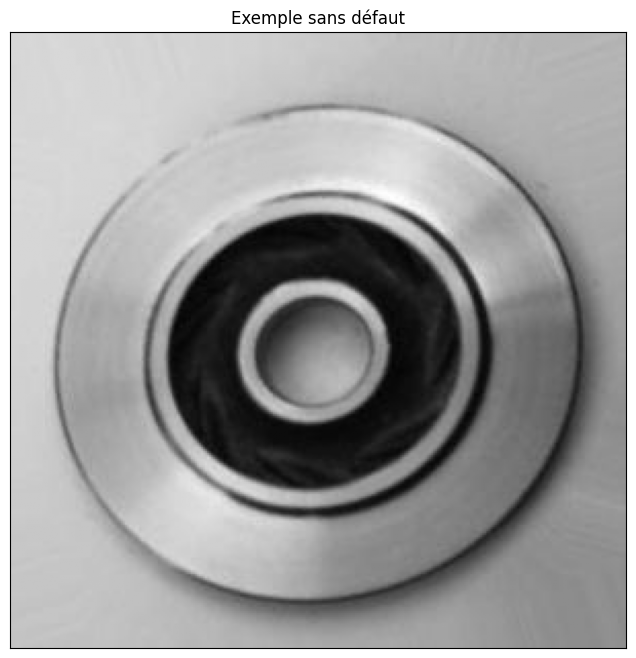

In [6]:
plot_simple_image(img_ok, "Exemple sans défaut", cmap='gray')


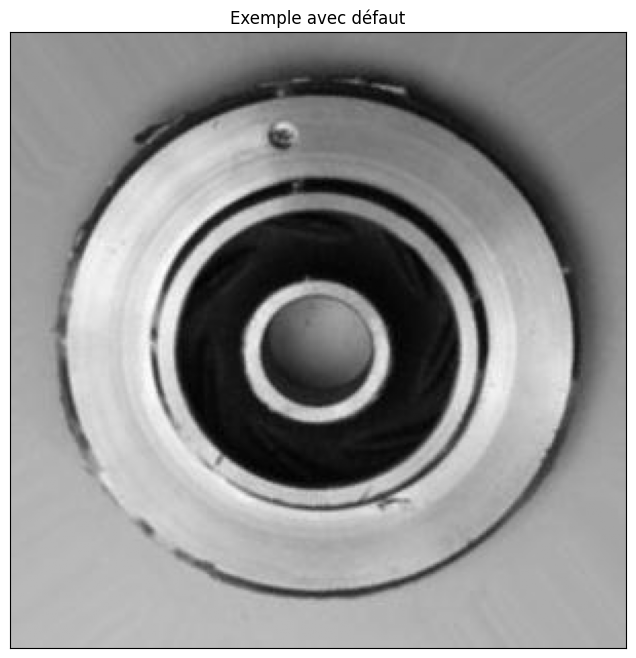

In [7]:
plot_simple_image(img_def, "Exemple avec défaut", cmap='gray')

Proportion d'échantillons normaux : 42.69%
Proportion d'échantillons anormaux : 57.31%


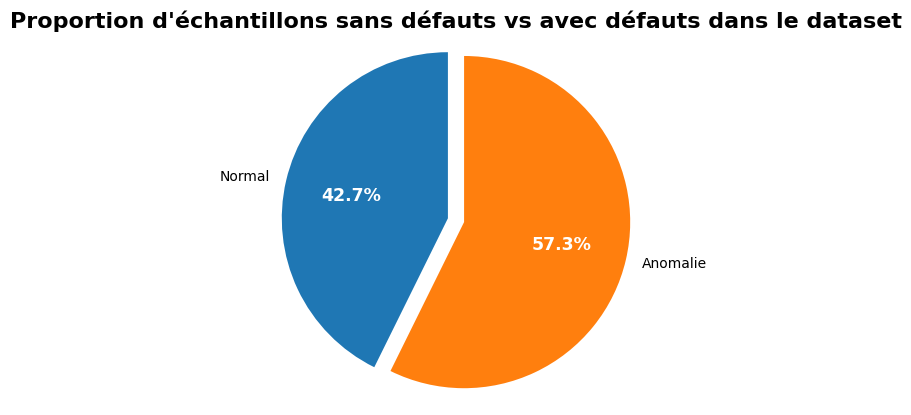

In [8]:
normal_samples_proportion = df[df["label"]=='ok_front'].shape[0]/df.shape[0]
abnormal_samples_proportion = df[df["label"]=='def_front'].shape[0]/df.shape[0]

print(f"Proportion d'échantillons normaux : {normal_samples_proportion:.2%}")
print(f"Proportion d'échantillons anormaux : {abnormal_samples_proportion:.2%}")

proportions = [normal_samples_proportion, abnormal_samples_proportion]
labels = ['Normal', 'Anomalie']

fig, ax = plt.subplots()
_, _, autopcts = ax.pie(proportions, labels=labels, autopct='%1.1f%%', startangle=90, explode=(0.05, 0.05))
plt.title("Proportion d'échantillons sans défauts vs avec défauts dans le dataset", fontweight="bold", fontsize=16)
plt.setp(autopcts, **{'color':'white', 'weight':'bold', 'fontsize':12.5})
plt.axis('equal')
plt.show()


In [13]:
root_dir = "../data/casting_data/"
transform = transforms.Compose([transforms.Resize((300, 300)), transforms.ToTensor()])

dataset_train = datasets.ImageFolder(root=root_dir+'train', transform=transform)
dataset_test = datasets.ImageFolder(root=root_dir+'test', transform=transform)

dataloader_train = DataLoader(dataset_train, batch_size=32, shuffle=True)
dataloader_test = DataLoader(dataset_test, batch_size=32, shuffle=True)

Dataset size: 6633
Shape X : torch.Size([32, 3, 300, 300])
Shape y : torch.Size([32])


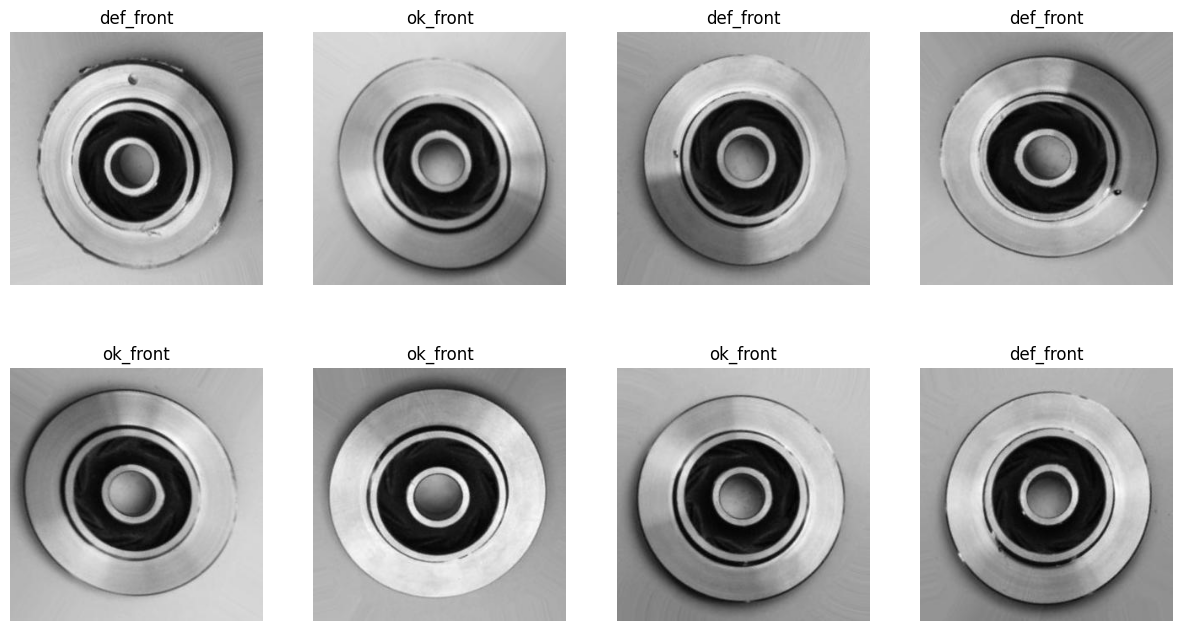

In [14]:
print(f"Dataset size: {len(dataset_train)}")

X_t, y_t = next(iter(dataloader_train))
print(f"Shape X : {X_t.shape}")
print(f"Shape y : {y_t.shape}")
plt.figure(figsize=(15,8))
j=1
for i in np.random.randint(0, len(X_t), size=[8]):
    plt.subplot(2,4,j)
    plt.axis('off')
    im = X_t[i].permute(1, 2, 0)
    plt.imshow(im)
    plt.title(dataset_train.classes[y_t[i].item()])
    j+=1
plt.show()